In [1]:
import os; os.chdir("..")

In [ ]:
from permacache import stable_hash

from orthogonal_dfa.analysis.nonlinear_motif_miner import (
    ScoreOracle,
    marginal_records_until,
)
from orthogonal_dfa.analysis.nonlinear_motif_miner_plot import plot_top_motifs
from orthogonal_dfa.data.exon import default_exon
from orthogonal_dfa.l_star.examples.gate_composition_residual import (
    fit_gate_composition_residual,
)
from orthogonal_dfa.l_star.examples.spliceai_oracle import flanks, run_over_middles
from orthogonal_dfa.spliceai.exon_score import SpliceAIExonScore, device_of
from orthogonal_dfa.spliceai.load_model import load_spliceai

### The oracle

SpliceAI's exon score minus a per-length-bin monotonic-gate bag-of-k-mers prediction, so
composition is removed but positional structure is not. The miner itself knows none of
this — it just gets a callable from sequences of symbol indices to scores.

In [ ]:
class GateResidualExonScore(ScoreOracle):
    """SpliceAI's exon score minus a per-length-bin monotonic-gate bag-of-k-mers
    prediction, so composition is removed but positional structure is not."""

    alphabet = "ACGT"

    def __init__(self, exon, spliceai_model, *, device=None, chunk=1024, **fit_kw):
        self.exon = exon
        self.chunk = chunk
        self.fit_kw = fit_kw
        self.score_model = SpliceAIExonScore(spliceai_model).eval()
        self.residual = fit_gate_composition_residual(
            self.score_model, exon, device=device, **fit_kw
        )
        self.device = device_of(self.score_model, device)
        self.flank_l, self.flank_r = flanks(exon)

    @property
    def length(self):
        return self.exon.random_text_length

    def scores(self, seqs):
        return run_over_middles(
            self.residual,
            self.flank_l,
            self.flank_r,
            seqs,
            device=self.device,
            chunk=self.chunk,
        )

    def hash_payload(self):
        return [
            stable_hash(self.score_model, version=2),
            stable_hash(self.exon),
            stable_hash(self.fit_kw),
        ]

In [ ]:
oracle = GateResidualExonScore(default_exon, load_spliceai(400, 0))

### Marginal-benefit ranking, lengths 1–4 (adaptive)
Same adaptive marginal scan, capped at 4-mers.

In [3]:
records4, info4 = marginal_records_until(
    oracle, 4, 0.04, contexts_per_round=200, max_contexts=16000
)

In [4]:
print(info4["n_contexts"], "contexts; achieved bound:", round(info4["bound"], 3))

3200 contexts; achieved bound per k: {1: 0.014, 2: 0.024, 3: 0.034, 4: 0.039}


In [5]:
for r in records4[:30]:
    print(r)

TAG [k=3]  marginal=0.2732  |effect|=0.4294
GGTA [k=4]  marginal=0.2680  |effect|=0.4349
TGA [k=3]  marginal=0.2563  |effect|=0.4033
AGGT [k=4]  marginal=0.2544  |effect|=0.4253
TAA [k=3]  marginal=0.2491  |effect|=0.4258
GTAA [k=4]  marginal=0.2441  |effect|=0.4754
TAAG [k=4]  marginal=0.2091  |effect|=0.4607
TAGG [k=4]  marginal=0.2016  |effect|=0.4709
AG [k=2]  marginal=0.2011  |effect|=0.2500
TA [k=2]  marginal=0.2004  |effect|=0.2843
GTAT [k=4]  marginal=0.2000  |effect|=0.2961
GGT [k=3]  marginal=0.1995  |effect|=0.2925
GTA [k=3]  marginal=0.1992  |effect|=0.3417
AGTA [k=4]  marginal=0.1974  |effect|=0.3539
AGG [k=3]  marginal=0.1926  |effect|=0.3187
AAGT [k=4]  marginal=0.1919  |effect|=0.3106
AAGG [k=4]  marginal=0.1895  |effect|=0.3301
GTAC [k=4]  marginal=0.1895  |effect|=0.2733
CGGT [k=4]  marginal=0.1892  |effect|=0.2712
AGGA [k=4]  marginal=0.1869  |effect|=0.3046
GGTT [k=4]  marginal=0.1844  |effect|=0.2722
GATT [k=4]  marginal=0.1839  |effect|=0.2632
AAG [k=3]  marginal=

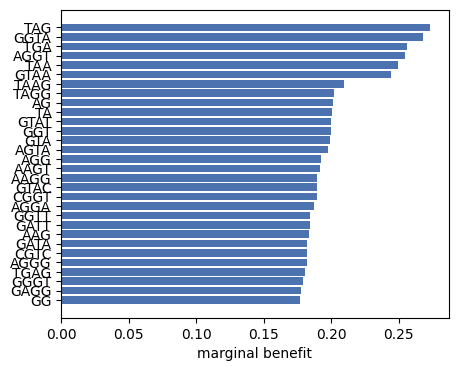

In [6]:
plot_top_motifs(records4, top=30);

### Marginal-benefit ranking, lengths 1–6 (adaptive)
Rank every k-mer (k=1..6) by *marginal benefit* — the effect not explained by its best contained (k-1)-mer. Sampling is adaptive: it keeps drawing fresh contexts until the winner's-curse bound on every length's top marginal is below `target_error`, so the 6-mer ranking is trustworthy, not noise. `info` reports the contexts used and the bound achieved.

In [7]:
records, info = marginal_records_until(
    oracle, 6, 0.04, contexts_per_round=200, max_contexts=16000
)

In [8]:
print(info["n_contexts"], "contexts; achieved bound:", round(info["bound"], 3))

8600 contexts; achieved bound per k: {1: 0.009, 2: 0.015, 3: 0.021, 4: 0.024, 5: 0.029, 6: 0.04}


In [9]:
for r in records[:30]:
    print(r)

GGTAAG [k=6]  marginal=0.5115  |effect|=0.8748
GTAAGT [k=6]  marginal=0.4136  |effect|=0.8059
AGGTA [k=5]  marginal=0.3600  |effect|=0.6328
GGTAGG [k=6]  marginal=0.3533  |effect|=0.6078
GTAAG [k=5]  marginal=0.3472  |effect|=0.5859
GGTGAG [k=6]  marginal=0.3435  |effect|=0.6098
AGGTAA [k=6]  marginal=0.3400  |effect|=0.8254
GTGAGT [k=6]  marginal=0.3397  |effect|=0.6173
TAGGTA [k=6]  marginal=0.3277  |effect|=0.6967
GGTAA [k=5]  marginal=0.3116  |effect|=0.5909
GTAGGT [k=6]  marginal=0.2866  |effect|=0.5960
AGGTAG [k=6]  marginal=0.2866  |effect|=0.6259
GGTACG [k=6]  marginal=0.2855  |effect|=0.5151
GGTATG [k=6]  marginal=0.2807  |effect|=0.5205
AGGTGA [k=6]  marginal=0.2803  |effect|=0.5814
TAG [k=3]  marginal=0.2770  |effect|=0.4326
GAATAC [k=6]  marginal=0.2695  |effect|=0.3155
GAATAT [k=6]  marginal=0.2665  |effect|=0.3344
GGTA [k=4]  marginal=0.2653  |effect|=0.4320
TGA [k=3]  marginal=0.2644  |effect|=0.4131
TAAGGT [k=6]  marginal=0.2622  |effect|=0.5946
TAA [k=3]  marginal=0.25

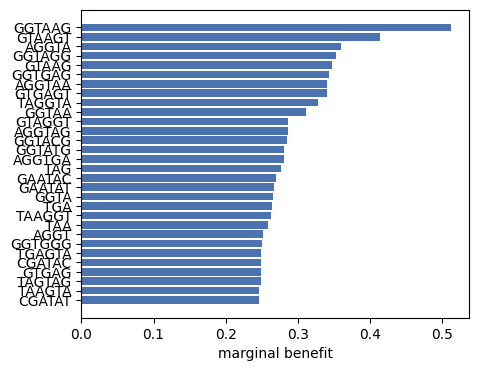

In [10]:
plot_top_motifs(records, top=30);